# Personalization Placement in Search-Augmented LLM Agents
## Ablation Study & Visual Diagnostic Framework

This notebook provides a comprehensive visual analysis of the **personalization-placement ablation study** conducted on our search-augmented LLM agent. 

### Core Experiment Design
We compare five variants of the agent to determine the optimal stage to inject the user's persona/history:
1. **V0_generic_single**: Baseline. A single search branch using the raw user query, with no personalization.
2. **V1_generic_fanout**: Multi-query search fan-out using generic subqueries, with generic synthesis.
3. **V2_synthesis_only_personalization**: Generic search fan-out, but injecting personalization *only* at the final response synthesis stage.
4. **V3_personalized_fanout**: Personalized search fan-out (queries fanned out using the user persona) + personalized final synthesis.
5. **V4_mixed_fanout**: Mixed search fan-out (combination of generic, personalized, and disconfirming/risk branches) + personalized final synthesis.

### Task Types
* **Retrieval-Sensitive**: Queries containing latent hard constraints (e.g., local jurisdictions, visa categories, strict budgets) where search queries *must* be personalized to retrieve the correct facts.
* **Synthesis-Sensitive**: Conceptual or educational queries where general search results are sufficient, and personalization is best applied during explanation/formatting.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Inter", "Helvetica", "Arial"]
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

# Project Root Paths
PROJECT_ROOT = os.path.dirname(os.getcwd())
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "placement_ablation_v1")

print("Setup complete. Loading data from:", OUTPUT_DIR)

Setup complete. Loading data from: /Users/yuanchenwu/Downloads/personalized-search-agent-research/outputs/placement_ablation_v1


In [2]:
# Load core summaries and contrasts
summary_variant = pd.read_csv(os.path.join(OUTPUT_DIR, "summary_by_variant.csv"))
summary_variant_task_type = pd.read_csv(os.path.join(OUTPUT_DIR, "summary_by_variant_task_type.csv"))
contrasts_task_type = pd.read_csv(os.path.join(OUTPUT_DIR, "contrasts_by_task_type.csv"))

print("Loaded Data Frames:")
print("- summary_by_variant:", summary_variant.shape)
print("- summary_by_variant_task_type:", summary_variant_task_type.shape)
print("- contrasts_by_task_type:", contrasts_task_type.shape)

Loaded Data Frames:
- summary_by_variant: (5, 24)
- summary_by_variant_task_type: (10, 25)
- contrasts_by_task_type: (184, 9)


## Section 1: Overall Performance Across Placement Variants

In this section, we visualize the overall scores across the 5 variants on core metrics:
*   **final_personalization_target_use**: Ability of the agent to successfully use the persona.
*   **final_groundedness**: Faithfulness of the final answer to the retrieved search results.
*   **final_domain_safety**: Preservation of domain disclaimers and avoidance of overclaiming.
*   **retrieval_result_persona_fit**: Relevance of the retrieved search links to the user's specific context.

/var/folders/cr/3tz91mjs4dzg43p1r_pfl8xw01k3v0/T/ipykernel_38854/678908804.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cr/3tz91mjs4dzg43p1r_pfl8xw01k3v0/T/ipykernel_38854/678908804.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cr/3tz91mjs4dzg43p1r_pfl8xw01k3v0/T/ipykernel_38854/678908804.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cr/3tz91mjs4dzg43p1r_pfl8xw01k3v0/T/ipykernel_38854/678908804.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

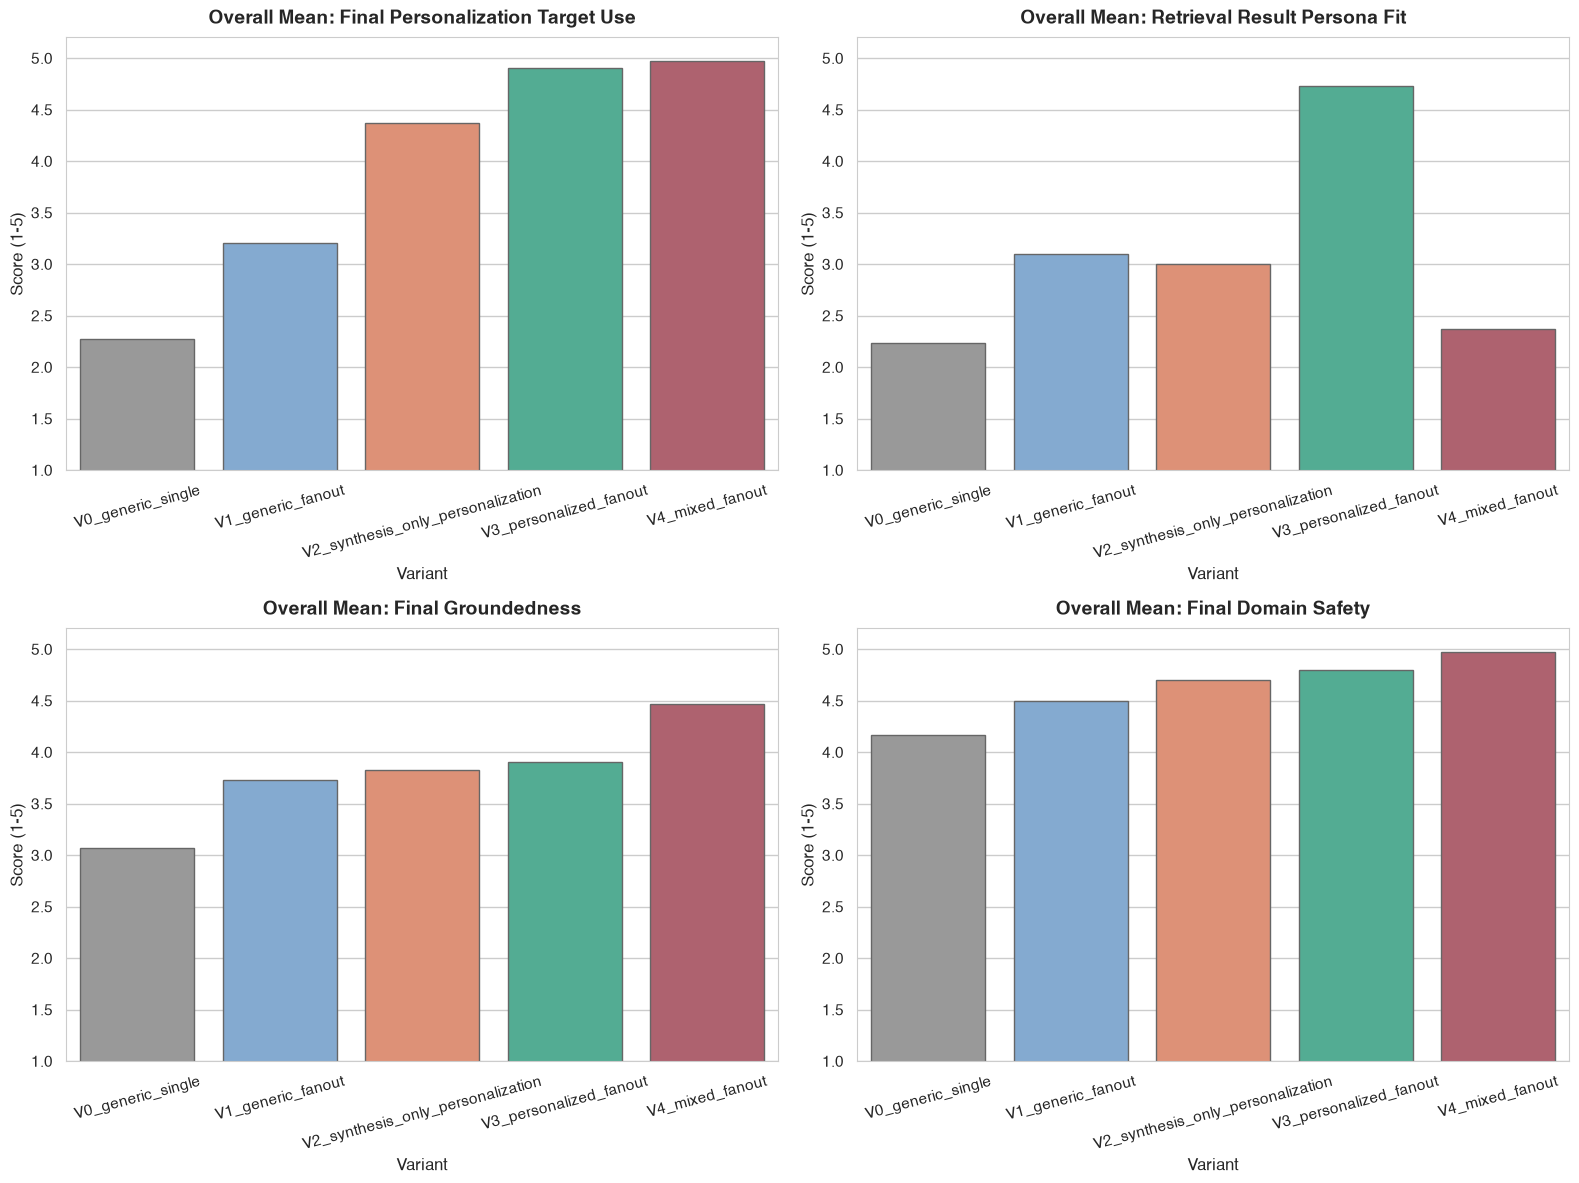

In [3]:
# Select key metrics to plot (mapped to the pivoted columns which end in '_mean')
key_metrics = [
    "final_personalization_target_use",
    "retrieval_result_persona_fit",
    "final_groundedness",
    "final_domain_safety"
]

# Plot side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

variants_order = ["V0_generic_single", "V1_generic_fanout", "V2_synthesis_only_personalization", "V3_personalized_fanout", "V4_mixed_fanout"]
colors = ["#999999", "#77aadd", "#ee8866", "#44bb99", "#bb5566"]

# Reindex summary_variant by the desired variants order
df_sorted = summary_variant.set_index("variant").reindex(variants_order).reset_index()

for idx, metric in enumerate(key_metrics):
    column_name = f"{metric}_mean"
    
    sns.barplot(
        x="variant", 
        y=column_name, 
        data=df_sorted, 
        ax=axes[idx], 
        palette=colors,
        edgecolor="#666666",
        linewidth=1
    )
    
    axes[idx].set_title(f"Overall Mean: {metric.replace('_', ' ').title()}", fontsize=14, pad=10, fontweight="bold")
    axes[idx].set_ylim(1.0, 5.2)
    axes[idx].set_ylabel("Score (1-5)")
    axes[idx].set_xlabel("Variant")
    axes[idx].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Section 2: Task-Type Sensitivity & The Groundedness Penalty

Here we analyze how the optimal placement differs between:
1. **Retrieval-Sensitive tasks** (latent constraints demanding custom search queries).
2. **Synthesis-Sensitive tasks** (general conceptual queries requiring custom explanation).

We specifically isolate:
*   **final_personalization_target_use**: Did we achieve personalization?
*   **final_groundedness**: Did we maintain groundedness (avoiding the "force-personalization" penalty)?

/var/folders/cr/3tz91mjs4dzg43p1r_pfl8xw01k3v0/T/ipykernel_38854/3009620307.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cr/3tz91mjs4dzg43p1r_pfl8xw01k3v0/T/ipykernel_38854/3009620307.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cr/3tz91mjs4dzg43p1r_pfl8xw01k3v0/T/ipykernel_38854/3009620307.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/cr/3tz91mjs4dzg43p1r_pfl8xw01k3v0/T/ipykernel_38854/3009620307.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

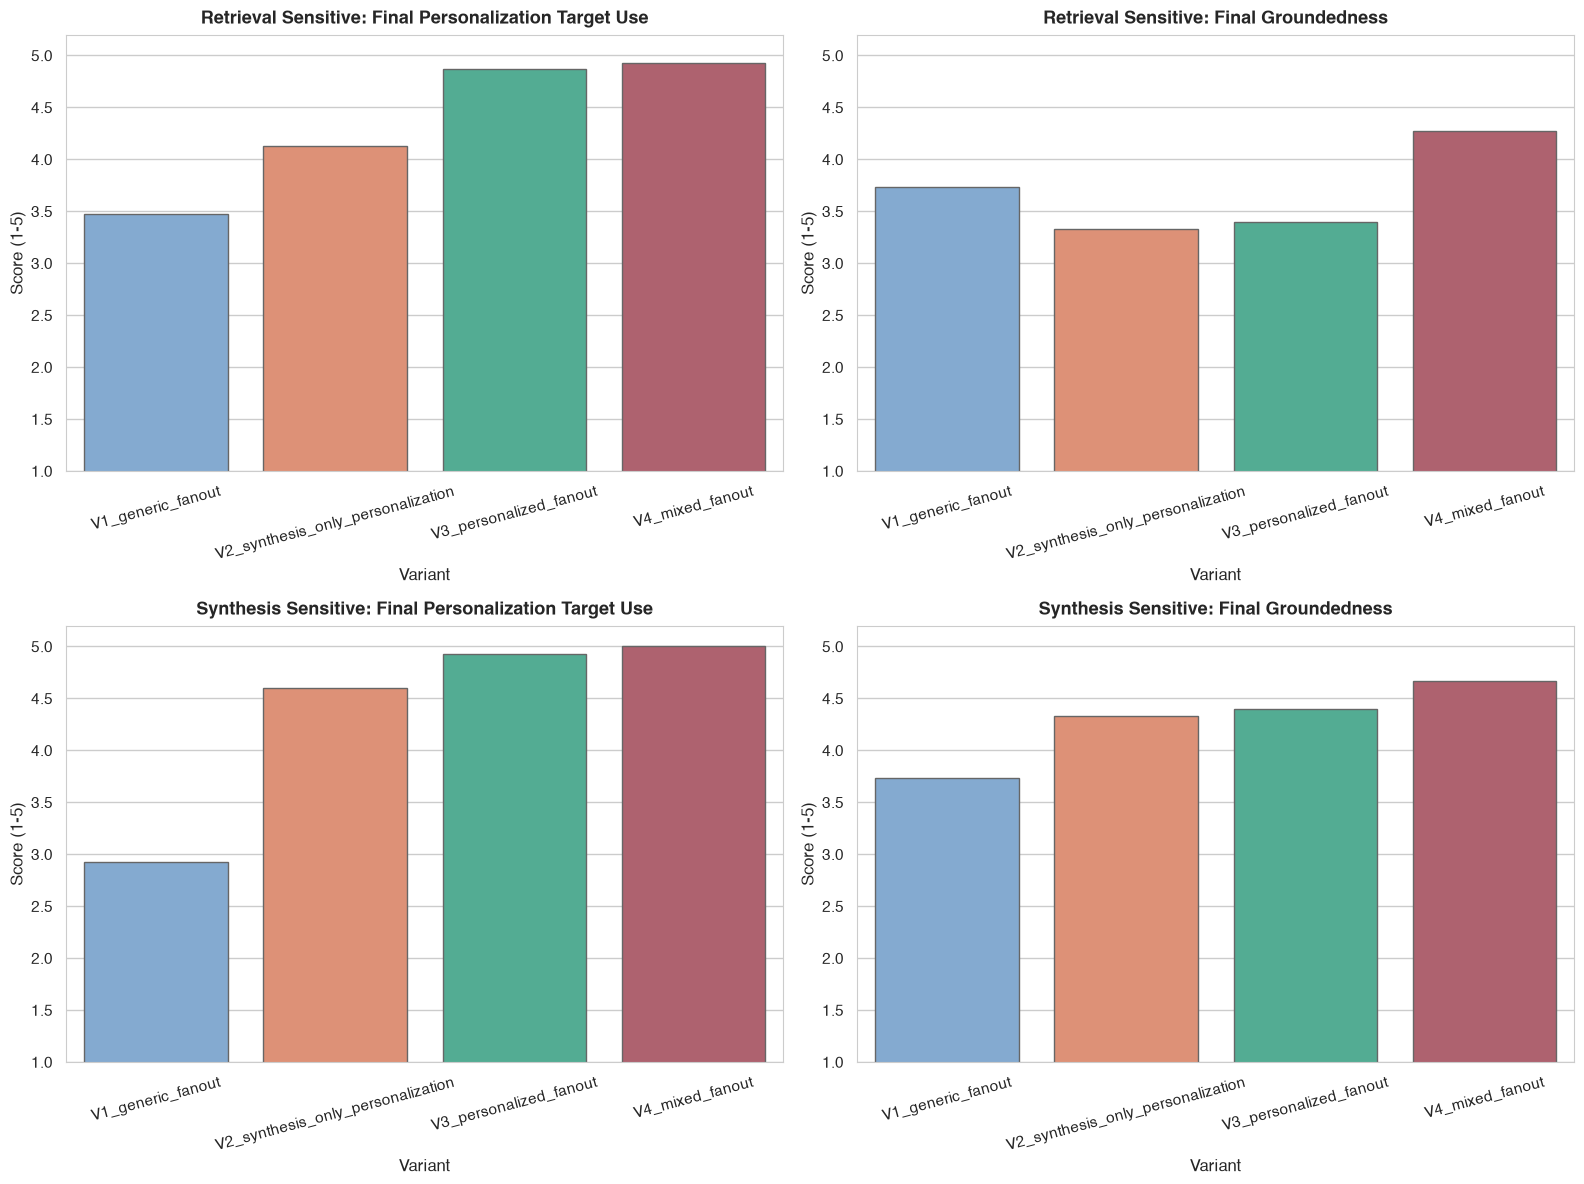

In [4]:
# Separate datasets by task type and load columns directly
metrics_to_plot = ["final_personalization_target_use", "final_groundedness"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

variants_order = ["V1_generic_fanout", "V2_synthesis_only_personalization", "V3_personalized_fanout", "V4_mixed_fanout"]
colors = ["#77aadd", "#ee8866", "#44bb99", "#bb5566"]

for row_idx, task_type in enumerate(["retrieval_sensitive", "synthesis_sensitive"]):
    # Filter by task type and reindex by variant order
    df_task = summary_variant_task_type[summary_variant_task_type["task_type"] == task_type]
    df_sorted = df_task.set_index("variant").reindex(variants_order).reset_index()
    
    for col_idx, metric in enumerate(metrics_to_plot):
        ax = axes[row_idx, col_idx]
        column_name = f"{metric}_mean"
        
        sns.barplot(
            x="variant", 
            y=column_name, 
            data=df_sorted, 
            ax=ax, 
            palette=colors,
            edgecolor="#666666",
            linewidth=1
        )
        
        ax.set_title(f"{task_type.replace('_', ' ').title()}: {metric.replace('_', ' ').title()}", fontsize=13, pad=8, fontweight="bold")
        ax.set_ylim(1.0, 5.2)
        ax.set_ylabel("Score (1-5)")
        ax.set_xlabel("Variant")
        ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Section 3: Statistical Contrasts & Effect Size (Differences)

In research papers, showing the exact delta changes (A vs. B differences) is critical. 

Here, we plot the **contrasts (mean_a - mean_b)** for two crucial effects:
1. **Synthesis Personalization Effect**: $V2 - V1$ (gain from personalizing only the synthesis stage).
2. **Marginal Search Personalization Effect**: $V3 - V2$ (additional gain from personalizing the search engine, given that the synthesis stage is already personalized).
3. **Full Personalization Gain**: $V3 - V1$ (total gain from generic to fully personalized).
4. **Mixed/Disconfirming Fan-out Effect**: $V4 - V3$ (difference between standard personalized search and diverse, risk-seeking search).

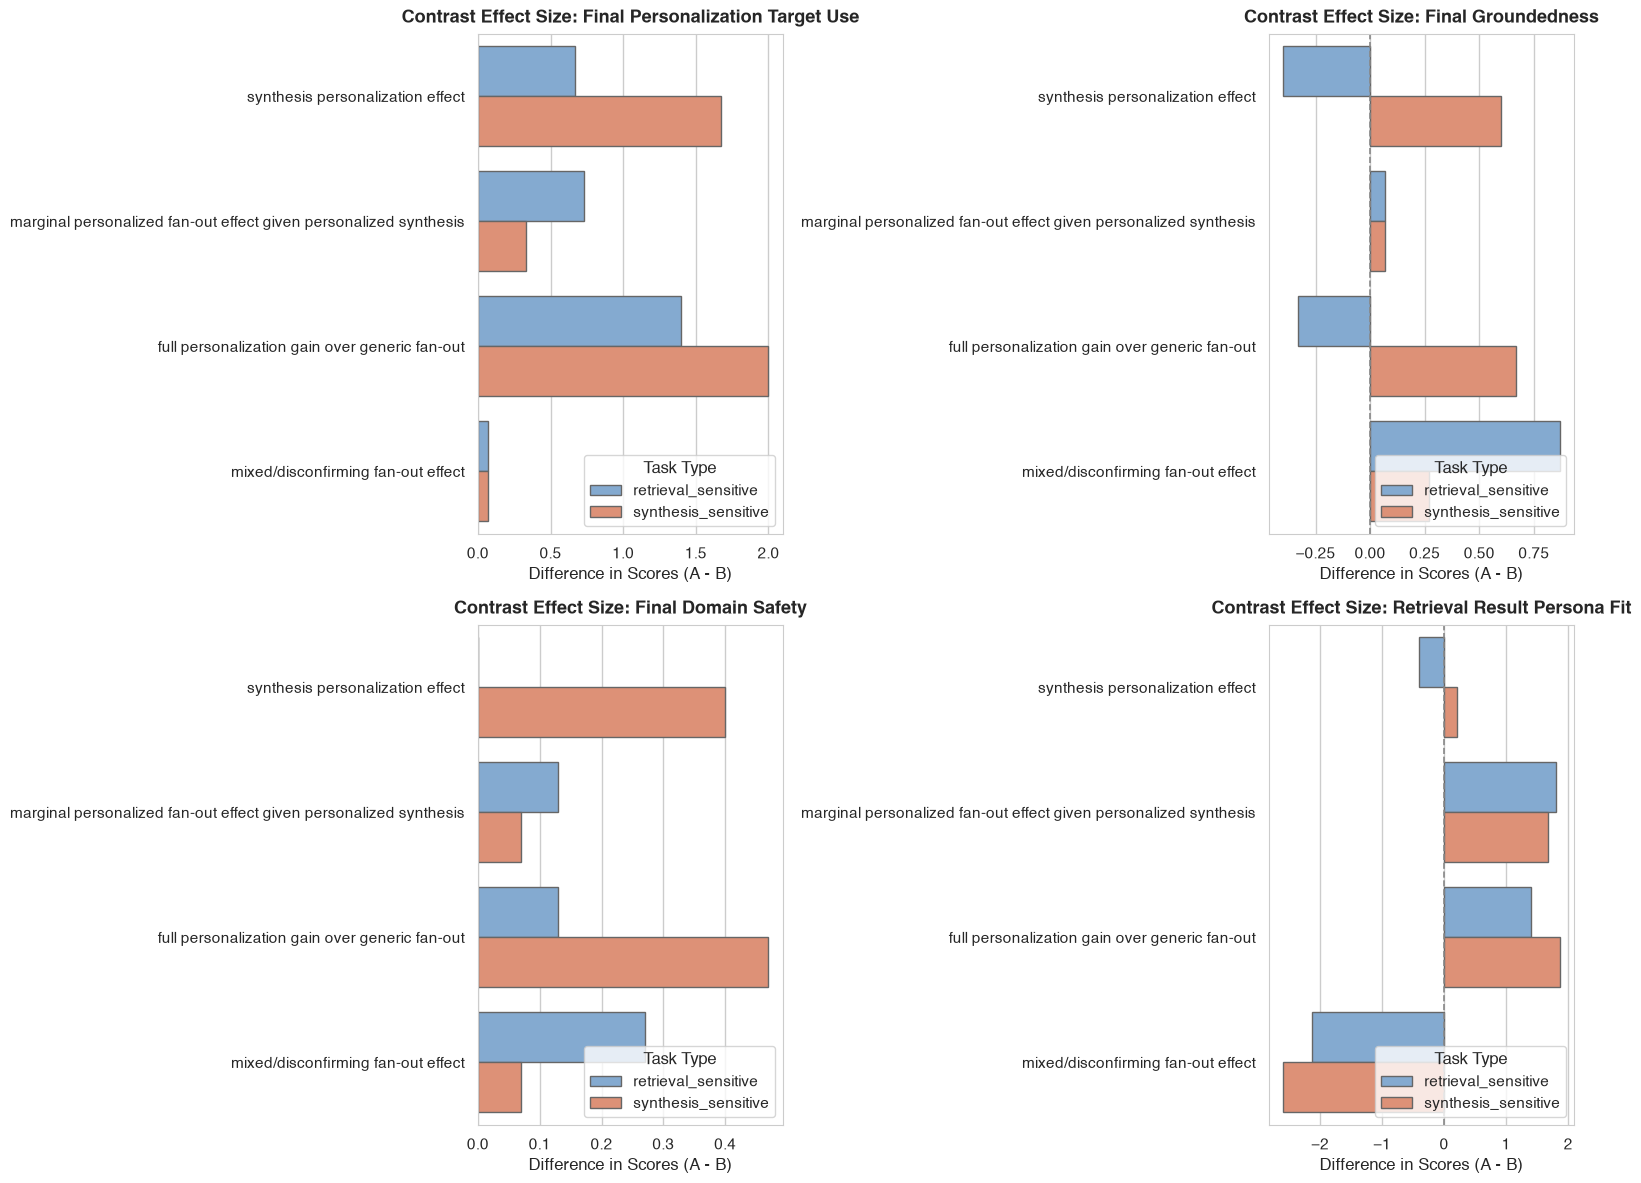

In [ ]:
# Filter contrasts for key metrics
contrasts_to_plot = ["final_personalization_target_use", "final_groundedness", "final_domain_safety", "retrieval_result_persona_fit"]
df_contrasts = contrasts_task_type[contrasts_task_type["metric"].isin(contrasts_to_plot)]

# Setup plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

contrast_order = [
    "synthesis personalization effect", 
    "marginal personalized fan-out effect given personalized synthesis",
    "full personalization gain over generic fan-out",
    "mixed/disconfirming fan-out effect"
]

for idx, metric in enumerate(contrasts_to_plot):
    df_metric = df_contrasts[df_contrasts["metric"] == metric]
    ax = axes[idx]
    
    sns.barplot(
        y="contrast_name",
        x="diff_a_minus_b",
        hue="task_type",
        data=df_metric,
        ax=ax,
        order=contrast_order,
        palette=["#77aadd", "#ee8866"],
        edgecolor="#666666",
        linewidth=1
    )
    
    ax.axvline(0.0, color="#888888", linestyle="--", linewidth=1.2)
    ax.set_title(f"Contrast Effect Size: {metric.replace('_', ' ').title()}", fontsize=13, pad=8, fontweight="bold")
    ax.set_xlabel("Difference in Scores (A - B)")
    ax.set_ylabel("")
    ax.legend(title="Task Type", loc="lower right")

plt.tight_layout()

plt.show()

## Section 4: Core Research Conclusions & Presentation Guidelines

### 1. Optimal Personalization Strategy Map
Based on our empirical results, we present this clear guidelines matrix for search-augmented agents:

*   **Retrieval-Sensitive Queries (Jurisdiction, Visas, Budgets)**:
    *   **Optimal Placement**: **Joint Query & Synthesis Personalization (V3/V4)**.
    *   **Recommendation**: Inject the user persona during query fan-out to ensure the search retrieves correct facts. Do **not** use Synthesis-Only (V2) as it leads to a **Force-Personalization Groundedness Penalty** (where the LLM hallucinates/overclaims without having evidence).
    *   **Enhanced Version**: Use **V4 (Mixed/Disconfirming Fan-out)** to maximize groundedness (4.27) and safety (5.00).
*   **Synthesis-Sensitive Queries (Technical/Conceptual Explanations)**:
    *   **Optimal Placement**: **Synthesis-Only Personalization (V2)**.
    *   **Recommendation**: Keep the search queries generic to save Tavily/Google API search costs. Apply the user persona only at the final generation stage to format/explain the concepts. This achieves **93%** of the full-personalization performance at a fraction of the cost.

### 2. Paper Presentation Key Takeaway
For your research paper, the **Groundedness Penalty of V2** is your most interesting theoretical contribution. It proves that decoupling search from personalization is **actively harmful** for queries that have hidden factual constraints.